# Seaborn for EDA

Seaborn is a Python data visualization library built on top of Matplotlib. It provides a high-level interface for drawing attractive statistical graphics with less code.

**Key advantages over raw Matplotlib:**
- Built-in statistical estimations (confidence intervals, regression lines)
- Attractive default themes and color palettes
- Native support for pandas DataFrames
- Since v0.12: declarative `seaborn.objects` interface (`so.Plot`)

**Documentation:** https://seaborn.pydata.org

In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

# Load apartment data
df = pd.read_csv('../data/apartments_data_enriched_cleaned.csv', )
print('Shape:', df.shape)
df.head(3)

Shape: (774, 17)


,Unnamed: 0,web-scraper-order,address_raw,lat,lon,bfs_number,bfs_name,rooms,area,luxurious,price,price_per_m2,pop,pop_dens,emp,frg_pct,mean_taxable_income
0,0,1693998201-1,"Neuhusstrasse 6, 8630 Rüti ZH, ZH",47.252171,8.845797,118,Rüti (ZH),3.0,49.0,0,1441.0,29.41,12286,1221.272366,5053.0,24.841283,65362.042683
1,1,1693998233-172,"Widacherstrasse 5, 8630 Rüti ZH, ZH",47.252087,8.854919,118,Rüti (ZH),3.0,111.0,0,2600.0,23.42,12286,1221.272366,5053.0,24.841283,65362.042683
2,2,1693998256-331,"Widenweg 14, 8630 Rüti ZH, ZH",47.253670,8.853993,118,Rüti (ZH),3.0,58.0,0,1490.0,25.69,12286,1221.272366,5053.0,24.841283,65362.042683


---
## Univariate Plots

### `histplot` — Histogram with optional KDE

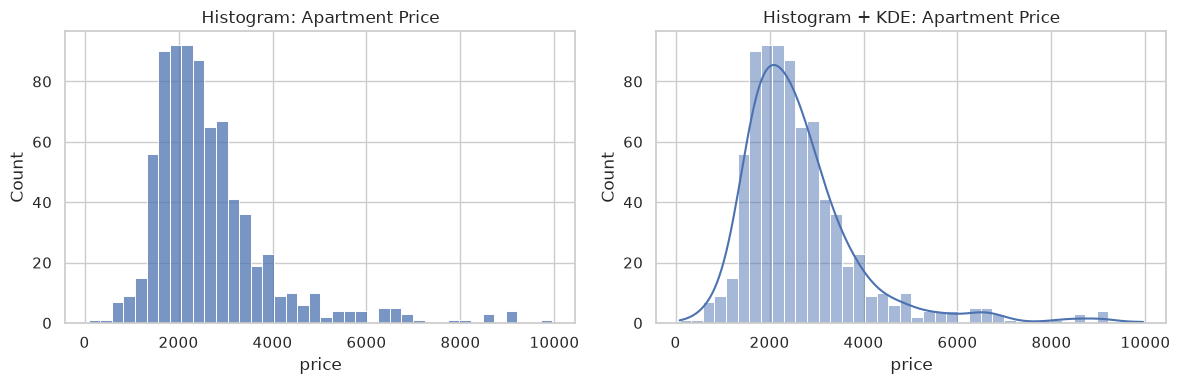

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
sns.histplot(data=df, x='price', bins=40, ax=axes[0])
axes[0].set_title('Histogram: Apartment Price')

# Histogram + KDE
sns.histplot(data=df, x='price', bins=40, kde=True, ax=axes[1])
axes[1].set_title('Histogram + KDE: Apartment Price')

plt.tight_layout()
plt.show()

### `kdeplot` — Kernel Density Estimate

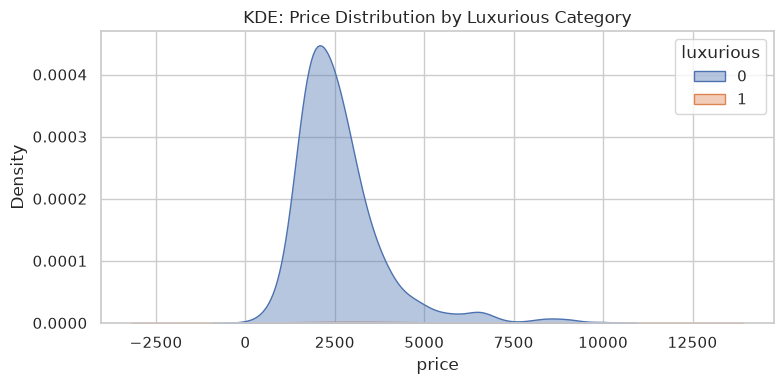

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(data=df, x='price', hue='luxurious', fill=True, alpha=0.4, ax=ax)
ax.set_title('KDE: Price Distribution by Luxurious Category')
plt.tight_layout()
plt.show()

### `boxplot` and `violinplot`

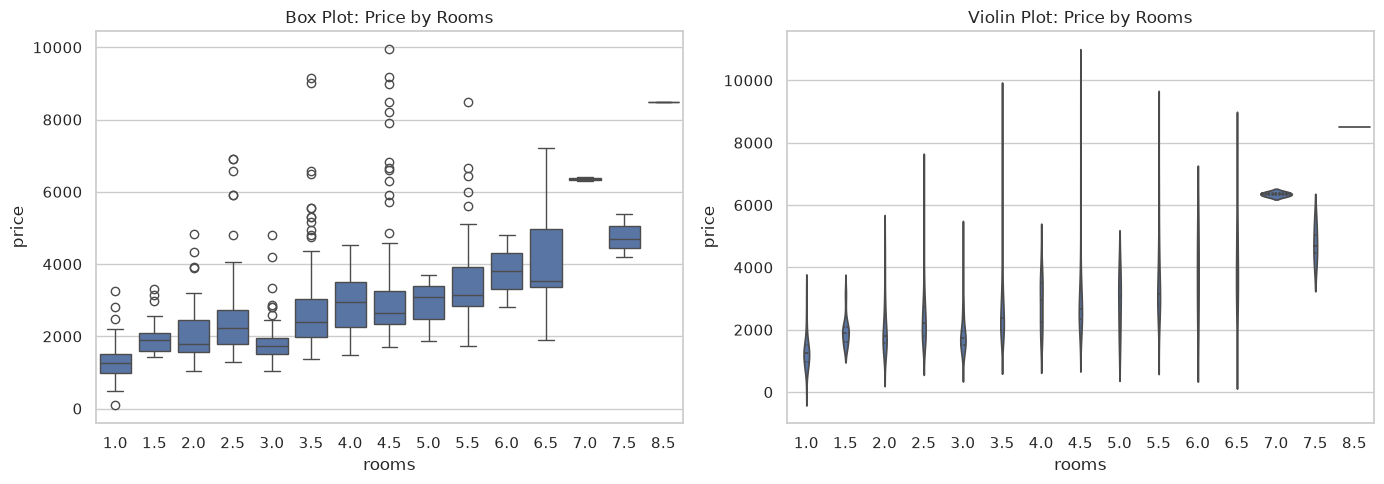

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='rooms', y='price', ax=axes[0])
axes[0].set_title('Box Plot: Price by Rooms')

sns.violinplot(data=df, x='rooms', y='price', ax=axes[1], inner='quartile')
axes[1].set_title('Violin Plot: Price by Rooms')

plt.tight_layout()
plt.show()

### `countplot` — Bar chart for categorical variables

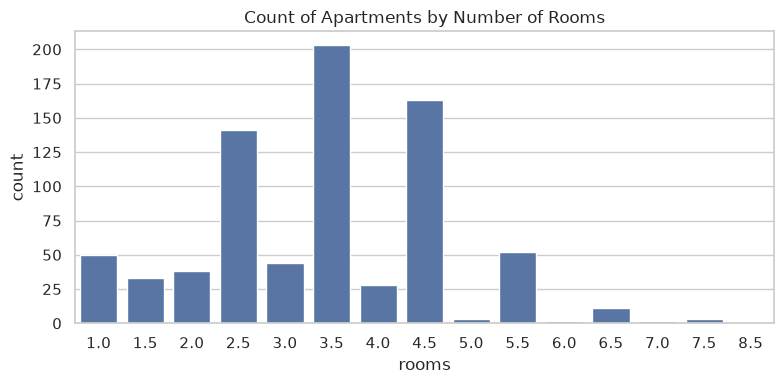

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(data=df, x='rooms', order=sorted(df['rooms'].unique()), ax=ax)
ax.set_title('Count of Apartments by Number of Rooms')
plt.tight_layout()
plt.show()

---
## Multivariate Plots

### `scatterplot` with hue and size

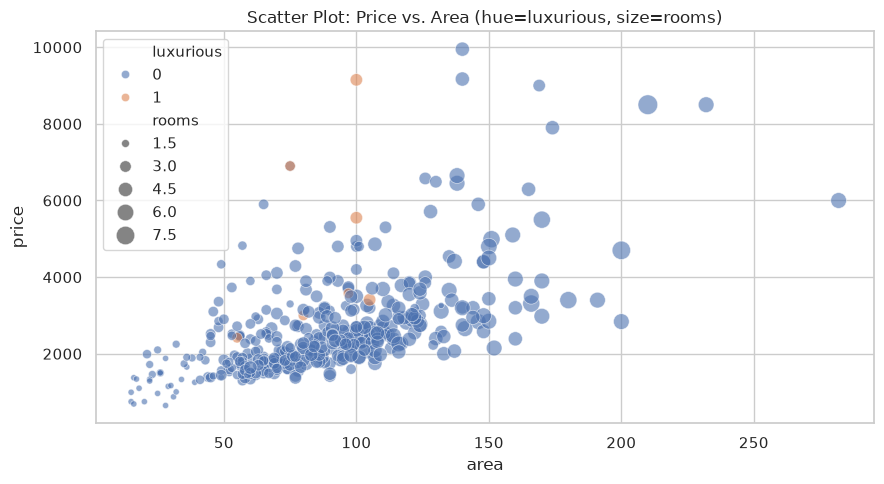

In [6]:
sample = df.dropna(subset=['price', 'area', 'rooms']).sample(400, random_state=42)

fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=sample, x='area', y='price', hue='luxurious', size='rooms',
                sizes=(20, 200), alpha=0.6, ax=ax)
ax.set_title('Scatter Plot: Price vs. Area (hue=luxurious, size=rooms)')
plt.tight_layout()
plt.show()

### `regplot` — Scatter plot with regression line

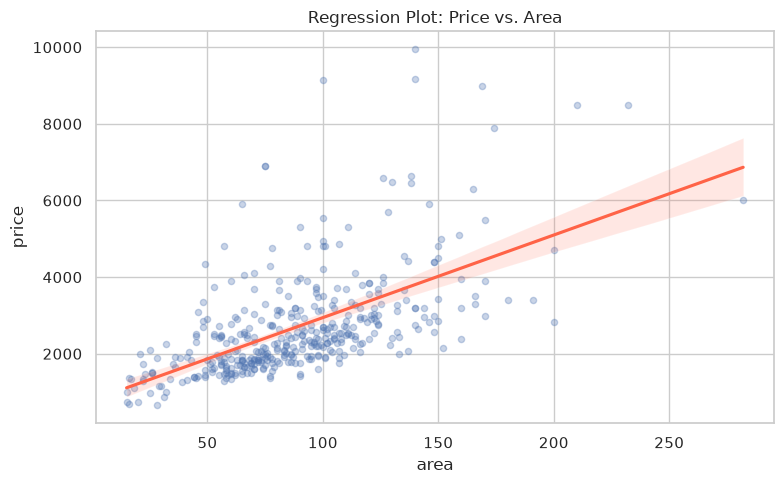

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(data=sample, x='area', y='price', scatter_kws={'alpha': 0.3, 's': 20},
            line_kws={'color': 'tomato'}, ax=ax)
ax.set_title('Regression Plot: Price vs. Area')
plt.tight_layout()
plt.show()

### `pairplot` — Scatter plot matrix

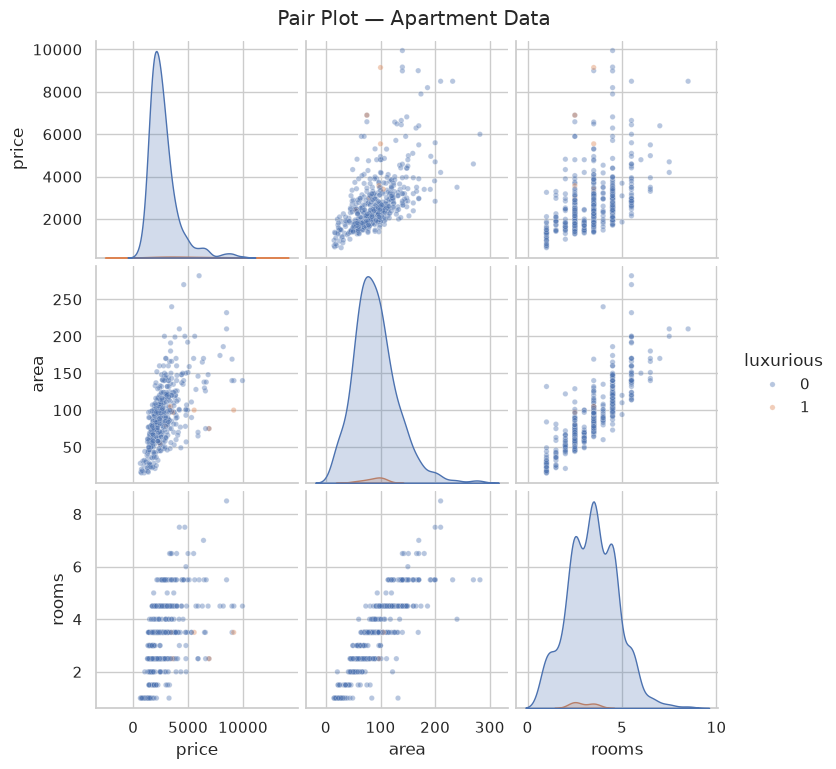

In [8]:
num_cols = ['price', 'area', 'rooms']
sample_small = df[num_cols + ['luxurious']].dropna().sample(500, random_state=42)

g = sns.pairplot(sample_small, hue='luxurious', diag_kind='kde',
                 plot_kws={'alpha': 0.4, 's': 15})
g.fig.suptitle('Pair Plot — Apartment Data', y=1.02)
plt.show()

### `heatmap` — Correlation heatmap

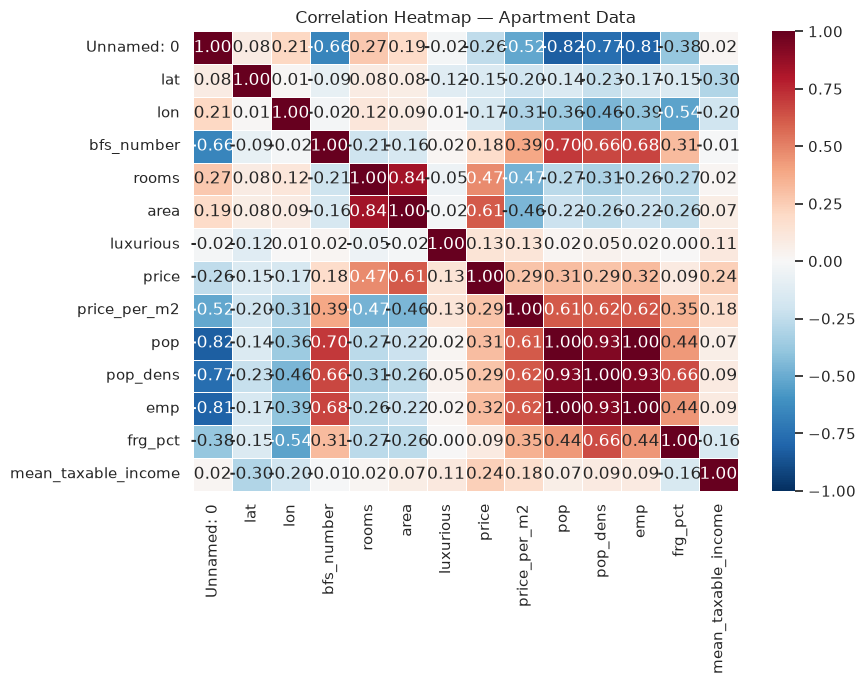

In [9]:
corr = df.corr(method='pearson', numeric_only=True)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap — Apartment Data')
plt.tight_layout()
plt.show()

---
## Seaborn Objects Interface (`so.Plot`)

Since seaborn v0.12, the new declarative `seaborn.objects` interface offers a grammar-of-graphics style API.

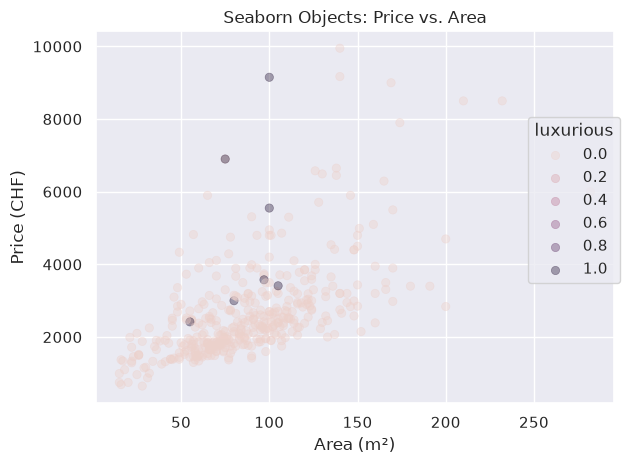

In [10]:
# Scatter plot using the objects interface
(
    so.Plot(sample, x='area', y='price', color='luxurious')
    .add(so.Dot(alpha=0.4))
    .label(title='Seaborn Objects: Price vs. Area', x='Area (m²)', y='Price (CHF)')
    .show()
)

## Jupyter notebook --footer info--
(please always provide this at the end of each notebook)

In [11]:
import os
import platform
import socket
from platform import python_version
from datetime import datetime

print('------------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('------------------------------------')

------------------------------------
POSIX
Linux | 6.8.0-1064-azure
Datetime: 2026-10-01 07:16:49
Python Version: 3.11.16
------------------------------------
